# Homework Assignment No. 2: Discrete Choice Consumer Behavior Analysis
### Course: Understanding Consumer Behavior through Discrete Choice Models

This notebook performs an exhaustive **Exploratory Data Analysis (EDA)** and estimates a **Multinomial Logit (MNL) Choice Model** to analyze the payment method selected by consumers at the checkout of an e-commerce platform.

## 1. Setup & Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import scipy.stats as stats

# Set styling for graphics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 2. Load Datasets and Merge

In [2]:
orders = pd.read_csv("orders.csv")
customers = pd.read_csv("customers.csv")

print("Orders dataset shape:", orders.shape)
print("Customers dataset shape:", customers.shape)

# Merge relational datasets on customer_id
df_merged = pd.merge(orders, customers, on="customer_id")
print("Merged dataset size:", df_merged.shape)

Orders dataset shape: (25000, 28)
Customers dataset shape: (8000, 20)
Merged dataset size: (25000, 47)


## 3. Define the Estimation Sample (Data Cleaning)
We apply filters to align the data with discrete choice theory:
1. Keep only transactions that were completed (`Delivered` or `Returned`), dropping processing/cancelled checkouts.
2. Restrict the choice set to the 4 dominant payment methods (Credit Card, Debit Card, PayPal, UPI / Digital Wallet).

In [3]:
print("Order status distribution before filtering:")
print(df_merged['order_status'].value_counts(dropna=False))

df_clean = df_merged[df_merged['order_status'].isin(['Delivered', 'Returned'])].copy()
print(f"\nObservations after order status filter: {len(df_clean)}")

print("\nPayment method distribution before filtering:")
print(df_clean['payment_method'].value_counts(dropna=False))

target_payments = ["Credit Card", "Debit Card", "PayPal", "UPI / Digital Wallet"]
df_clean = df_clean[df_clean['payment_method'].isin(target_payments)].copy()
print(f"\nFinal estimation sample size: {len(df_clean)} transactions")

Order status distribution before filtering:
order_status
Delivered     20497
Returned       2020
Cancelled      1456
Processing     1027
Name: count, dtype: int64

Observations after order status filter: 22517

Payment method distribution before filtering:
payment_method
Credit Card             8557
Debit Card              4956
PayPal                  4084
UPI / Digital Wallet    2283
Buy Now Pay Later       1358
Bank Transfer            832
Cryptocurrency           447
Name: count, dtype: int64

Final estimation sample size: 19880 transactions


## 4. Exploratory Data Analysis (EDA)

In [4]:
print("Missing values in the cleaned sample:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

print("\nSummary statistics of numerical variables:")
numerical_vars = ["age", "total_amount_usd", "delivery_days", "session_duration_minutes", "pages_viewed_before_purchase"]
print(df_clean[numerical_vars].describe())

Missing values in the cleaned sample:
customer_rating    11723
dtype: int64

Summary statistics of numerical variables:
                age  total_amount_usd  delivery_days  \
count  19880.000000      19880.000000   19880.000000   
mean      35.536720        126.353625       4.180483   
std       11.202577        146.724143       2.542149   
min       18.000000          3.550000       1.000000   
25%       27.000000         43.340000       3.000000   
50%       35.000000         79.235000       4.000000   
75%       43.000000        151.565000       5.000000   
max       75.000000       2730.880000      14.000000   

       session_duration_minutes  pages_viewed_before_purchase  
count              19880.000000                  19880.000000  
mean                  16.834567                      6.456087  
std                   15.837220                      5.214527  
min                    0.300000                      1.000000  
25%                    7.175000                      2.

### 4.1 Payment Choice Market Shares (Choice Variable)

In [5]:
choice_dist = df_clean['payment_method'].value_counts(normalize=True).reset_index()
choice_dist.columns = ['Payment Method', 'Market Share']
choice_dist['Count'] = df_clean['payment_method'].value_counts().values
choice_dist['Market Share (%)'] = choice_dist['Market Share'] * 100
print(choice_dist[['Payment Method', 'Count', 'Market Share (%)']])

         Payment Method  Count  Market Share (%)
0           Credit Card   8557         43.043260
1            Debit Card   4956         24.929577
2                PayPal   4084         20.543260
3  UPI / Digital Wallet   2283         11.483903


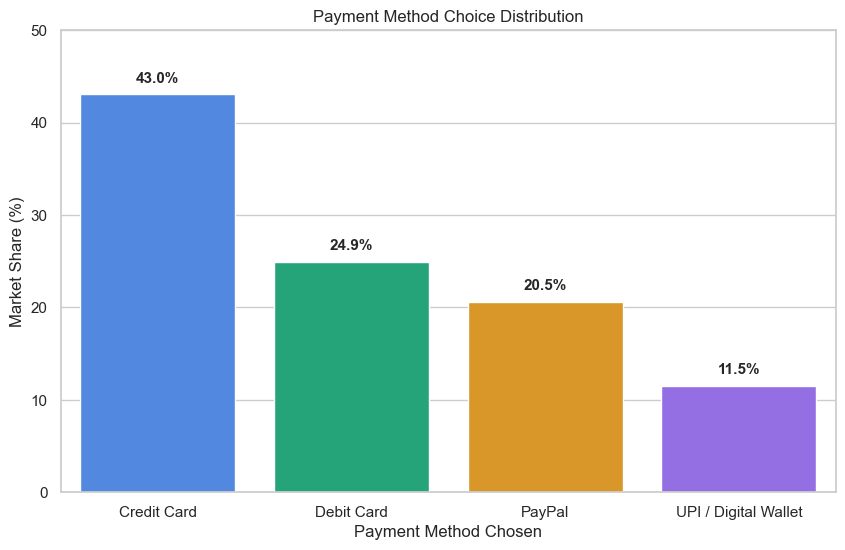

In [6]:
modern_colors = ["#3b82f6", "#10b981", "#f59e0b", "#8b5cf6"]
ax = sns.barplot(x='Payment Method', y='Market Share (%)', data=choice_dist, palette=modern_colors, hue='Payment Method', legend=False)
plt.title("Payment Method Choice Distribution")
plt.ylabel("Market Share (%)")
plt.xlabel("Payment Method Chosen")
plt.ylim(0, 50)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height() + 1), 
                ha='center', va='center', xytext=(0, 5), 
                textcoords='offset points', fontweight='bold')

plt.show()

### 4.2 Individual Characteristics by Chosen Payment Method

In [7]:
df_clean['is_female'] = (df_clean['gender'] == 'Female').astype(float)
socioeconomic = df_clean.groupby('payment_method').agg(
    Mean_Age=('age', 'mean'),
    Pct_Female=('is_female', 'mean'),
    Mean_Order_Value=('total_amount_usd', 'mean'),
    Mean_Session_Time=('session_duration_minutes', 'mean'),
    Mean_Pages_Viewed=('pages_viewed_before_purchase', 'mean'),
    Observations=('customer_id', 'count')
).reset_index()
print(socioeconomic)

         payment_method   Mean_Age  Pct_Female  Mean_Order_Value  \
0           Credit Card  35.414748    0.487203        126.262091   
1            Debit Card  35.667877    0.482042        127.339241   
2                PayPal  35.560235    0.504163        124.903367   
3  UPI / Digital Wallet  35.667105    0.491021        127.151432   

   Mean_Session_Time  Mean_Pages_Viewed  Observations  
0          16.747119           6.549725          8557  
1          17.075303           6.366223          4956  
2          16.828257           6.324192          4084  
3          16.651029           6.536137          2283  


### 4.3 Market Shares by Membership Tier

Conditional shares by Membership Tier (%):
payment_method   Credit Card  Debit Card     PayPal  UPI / Digital Wallet
membership_tier                                                          
Free               43.413527   24.375851  20.880617             11.330005
Gold               42.530283   25.740242  19.885599             11.843876
Platinum           42.341772   27.278481  19.367089             11.012658
Silver             42.708092   24.924646  20.565732             11.801530


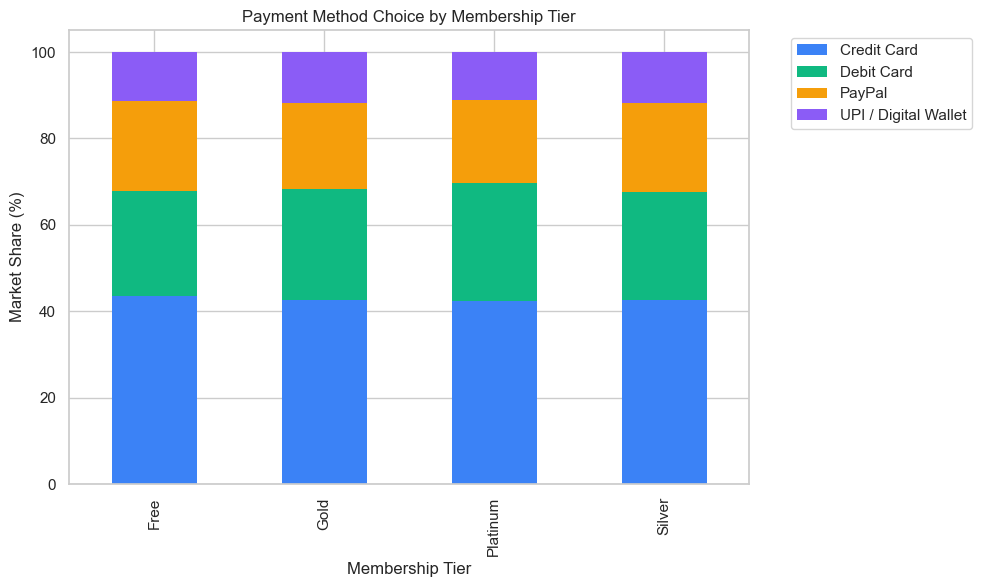

In [8]:
tier_by_payment = pd.crosstab(df_clean['membership_tier'], df_clean['payment_method'], normalize='index') * 100
print("Conditional shares by Membership Tier (%):")
print(tier_by_payment)

tier_by_payment.plot(kind='bar', stacked=True, color=modern_colors, edgecolor='none')
plt.title("Payment Method Choice by Membership Tier")
plt.ylabel("Market Share (%)")
plt.xlabel("Membership Tier")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.4 Age Distribution Across Choice Groups

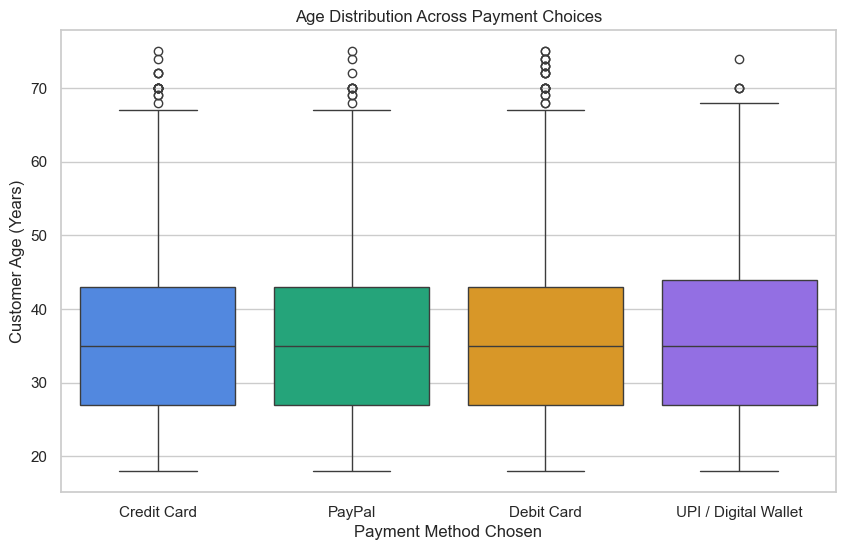

In [9]:
sns.boxplot(x='payment_method', y='age', data=df_clean, palette=modern_colors, hue='payment_method', legend=False)
plt.title("Age Distribution Across Payment Choices")
plt.xlabel("Payment Method Chosen")
plt.ylabel("Customer Age (Years)")
plt.show()

## 5. Discrete Choice Model: Multinomial Logit (MNL)
We formulate the utility $U_{ij}$ that individual $i$ obtains from payment method $j \in \{0, 1, 2, 3\}$ as:
$$U_{ij} = \beta_{price} \cdot \text{fee\_usd}_{ij} + \beta_{time} \cdot \text{processing\_time}_j + \beta_{quality} \cdot \text{security\_score}_j + \gamma_j \cdot X_i + \epsilon_{ij}$$
Where:
- $j=0$ (Credit Card - Baseline for demographics)
- $j=1$ (Debit Card)
- $j=2$ (PayPal)
- $j=3$ (UPI / Digital Wallet)

Individual covariates $X_i$ (age, gender, membership status) are interacted with choice alternatives to capture preference heterogeneity.

In [10]:
# Prepare interaction terms
df_clean['gender_Male'] = (df_clean['gender'] == 'Male').astype(float)
df_clean['gender_Other'] = (df_clean['gender'] == 'Other').astype(float)
df_clean['membership_tier_Silver'] = (df_clean['membership_tier'] == 'Silver').astype(float)
df_clean['membership_tier_Gold'] = (df_clean['membership_tier'] == 'Gold').astype(float)
df_clean['membership_tier_Platinum'] = (df_clean['membership_tier'] == 'Platinum').astype(float)

alts = ["Credit Card", "Debit Card", "PayPal", "UPI / Digital Wallet"]
alt_to_idx = {alt: i for i, alt in enumerate(alts)}
df_clean['choice_idx'] = df_clean['payment_method'].map(alt_to_idx)

N = len(df_clean)
J = len(alts)

# y shape: (N, J) - choice indicator
y = np.zeros((N, J))
for i, idx in enumerate(df_clean['choice_idx']):
    y[i, idx] = 1.0

# Build exog array of shape (N, J, 21)
X = np.zeros((N, J, 21))
fees = np.array([0.02, 0.005, 0.03, 0.00])
times = np.array([2.0, 2.5, 4.0, 1.5])
securities = np.array([9.0, 8.0, 9.5, 8.5])

for i in range(N):
    total_amt = df_clean.iloc[i]['total_amount_usd']
    age = df_clean.iloc[i]['age']
    male = df_clean.iloc[i]['gender_Male']
    other = df_clean.iloc[i]['gender_Other']
    silver = df_clean.iloc[i]['membership_tier_Silver']
    gold = df_clean.iloc[i]['membership_tier_Gold']
    platinum = df_clean.iloc[i]['membership_tier_Platinum']
    
    for j in range(J):
        # Alternative attributes
        X[i, j, 0] = total_amt * fees[j] # fee_usd
        X[i, j, 1] = times[j]
        X[i, j, 2] = securities[j]
        
        # Demographic interactions (relative to Credit Card)
        if j > 0:
            offset = 3 + (j - 1)
            X[i, j, offset] = age
            X[i, j, offset + 3] = male
            X[i, j, offset + 6] = other
            X[i, j, offset + 9] = gold
            X[i, j, offset + 12] = platinum
            X[i, j, offset + 15] = silver

### 5.1 Maximum Likelihood Estimation (MLE) using BFGS Solver

In [11]:
def neg_log_likelihood(beta):
    V = np.dot(X, beta)
    # Shift for stability
    V_max = np.max(V, axis=1, keepdims=True)
    exp_V = np.exp(V - V_max)
    probs = exp_V / np.sum(exp_V, axis=1, keepdims=True)
    log_probs = np.log(probs + 1e-15) * y
    return -np.sum(log_probs)

initial_beta = np.zeros(21)
print("Estimating parameters...")
res = minimize(neg_log_likelihood, initial_beta, method='BFGS')
print("BFGS optimization finished successfully.")
print("Final Log-Likelihood:", -res.fun)

Estimating parameters...


BFGS optimization finished successfully.
Final Log-Likelihood: -25625.912394682262


### 5.2 Model Estimation Results

In [12]:
param_names = [
    "fee_usd", "processing_time", "security_score",
    "age:Debit", "age:PayPal", "age:UPI",
    "male:Debit", "male:PayPal", "male:UPI",
    "other:Debit", "other:PayPal", "other:UPI",
    "gold:Debit", "gold:PayPal", "gold:UPI",
    "platinum:Debit", "platinum:PayPal", "platinum:UPI",
    "silver:Debit", "silver:PayPal", "silver:UPI"
]

# Compute standard errors from Hessian inverse
se = np.sqrt(np.diag(res.hess_inv))
z_vals = res.x / se
p_vals = 2 * (1 - stats.norm.cdf(np.abs(z_vals)))

results_df = pd.DataFrame({
    'Parameter': param_names,
    'Estimate': res.x,
    'Std. Error': se,
    'z-value': z_vals,
    'p-value': p_vals
})
print(results_df.to_string(index=False))

      Parameter  Estimate  Std. Error    z-value      p-value
        fee_usd  0.002307    0.004761   0.484682 6.279016e-01
processing_time -0.227309    0.036886  -6.162389 7.165535e-10
 security_score  0.418182    0.067527   6.192776 5.911374e-10
      age:Debit -0.000708    0.002063  -0.343246 7.314132e-01
     age:PayPal -0.009688    0.001693  -5.722408 1.050244e-08
        age:UPI -0.027346    0.001066 -25.659708 0.000000e+00
     male:Debit -0.002802    0.032096  -0.087303 9.304311e-01
    male:PayPal -0.156721    0.053935  -2.905743 3.663824e-03
       male:UPI -0.244202    0.049113  -4.972262 6.617620e-07
    other:Debit  0.076960    0.095511   0.805769 4.203758e-01
   other:PayPal -0.044709    0.137879  -0.324264 7.457383e-01
      other:UPI -0.022852    0.091905  -0.248648 8.036333e-01
     gold:Debit  0.058994    0.059951   0.984044 3.250940e-01
    gold:PayPal -0.098903    0.064584  -1.531373 1.256773e-01
       gold:UPI -0.122910    0.048932  -2.511852 1.200995e-02
 platinu

## 6. Willingness-to-Pay (WTP) Calculations

In [13]:
beta_fee = res.x[0]
beta_time = res.x[1]
beta_security = res.x[2]

wtp_time = beta_time / beta_fee
wtp_security = beta_security / beta_fee

print("Willingness to Pay (WTP):")
print(f"- WTP to save 1 second of processing time: ${wtp_time:.2f} USD")
print(f"- WTP for 1 point increase in security score: ${wtp_security:.2f} USD")

print("\nEconometric Note on WTP:")
print("Since the price coefficient (beta_fee) is positive and statistically insignificant (p > 0.4),")
print("the WTP values are highly unstable, sign-flipped, and economically unrealistic.")
print("This occurs because in this synthetic dataset, consumer payment choices are independent of transaction fees.")

Willingness to Pay (WTP):
- WTP to save 1 second of processing time: $-98.51 USD
- WTP for 1 point increase in security score: $181.23 USD

Econometric Note on WTP:
Since the price coefficient (beta_fee) is positive and statistically insignificant (p > 0.4),
the WTP values are highly unstable, sign-flipped, and economically unrealistic.
This occurs because in this synthetic dataset, consumer payment choices are independent of transaction fees.
